<a href="https://colab.research.google.com/github/jolied-14/MLE-F2025/blob/main/MLEProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLE Project F2025

Name: Jolie Dolan<br>
RIN: 662020565

In [ ]:
# Initial Setup
# Import libraries and load dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv('/content/sample_data/Data2.csv')

print("Dataset Loaded Successfully.\n")

# Show first rows
display(df.head())

# Dataset summary
print("\nDataset Info:")
print(df.info())

Dataset Loaded Successfully.



,Name,P1 _Convergence Length,P2 Divergence Length,P3_InletDiameter,P4_Throttle_Diameter,P5_ExitDiameter,P7_Pressure_Inlet,P6_Velocity
0,DP 0,15,15,12,3,15,1378950,119.130700
1,DP 1,28,30,21,1,9,474973,25.174023
2,DP 2,19,17,13,3,20,1285097,97.235954
3,DP 3,20,24,19,1,23,382353,28.955469
4,DP 4,13,14,11,3,13,822234,130.119600



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    1001 non-null   object 
 1   P1 _Convergence Length  1001 non-null   int64  
 2   P2 Divergence Length    1001 non-null   int64  
 3   P3_InletDiameter        1001 non-null   int64  
 4   P4_Throttle_Diameter    1001 non-null   int64  
 5   P5_ExitDiameter         1001 non-null   int64  
 6   P7_Pressure_Inlet       1001 non-null   int64  
 7   P6_Velocity             1001 non-null   float64
dtypes: float64(1), int64(6), object(1)
memory usage: 62.7+ KB
None


## Part 1: Decision Tree Utilization for Classifying Flow Regime

In [ ]:
# Solve Mach from area ratio using isentropic relations
from scipy.optimize import fsolve

gamma = 1.4

def area_mach_relation(M, AR, gamma=1.4):
    """Isentropic area-Mach relation set equal to AR."""
    return ((((2/(gamma+1)) * (1 + (gamma-1)/2 * M**2)))**((gamma+1)/(2*(gamma-1))) / M) - AR

def solve_mach(AR, supersonic=True):
    """Solve Mach from area ratio.
       If supersonic=True, solve for M > 1.
       Otherwise solve for M < 1."""
    if supersonic:
        M_initial = 2.0
    else:
        M_initial = 0.2
    M_solution = fsolve(area_mach_relation, M_initial, args=(AR,))
    return float(M_solution[0])

In [ ]:
import numpy as np
import pandas as pd

# constants
gamma = 1.4
P_ambient = 101325  # Pa

# Compute actual area ratios
A_throat = (np.pi/4) * (df['P4_Throttle_Diameter']**2)
A_exit = (np.pi/4) * (df['P5_ExitDiameter']**2)

df["AR_exit"] = A_exit / A_throat

# Solve for exit Mach (supersonic branch)
df["M_exit"] = df["AR_exit"].apply(lambda AR: solve_mach(AR, supersonic=True))
df["NPR_ideal"] = (1 + (gamma-1)/2 * df["M_exit"]**2)**(gamma/(gamma-1))

P_ambient = 101325  # Pa

df["NPR_actual"] = df["P7_Pressure_Inlet"] / P_ambient

def classify_regime(row, epsilon=0.05):
    NPR_a = row["NPR_actual"]
    NPR_i = row["NPR_ideal"]

    if NPR_a > NPR_i * (1 + epsilon):
        return "underexpanded"
    elif NPR_a < NPR_i * (1 - epsilon):
        return "overexpanded"
    else:
        return "ideally expanded"

df["FlowRegime"] = df.apply(classify_regime, axis=1)


/tmp/ipython-input-3209984569.py:18: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  M_solution = fsolve(area_mach_relation, M_initial, args=(AR,))


In [ ]:
df["FlowRegime"].value_counts()


,count
FlowRegime,
overexpanded,864
underexpanded,117
ideally expanded,20


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(df["FlowRegime"])

print("Encoder classes:", encoder.classes_)
print("Sample encoded labels:", y_encoded[:10])

Encoder classes: ['ideally expanded' 'overexpanded' 'underexpanded']
Sample encoded labels: [1 1 1 1 1 1 1 1 1 1]


### corrected method

In [ ]:
# train–test split + classifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# select features
feature_cols = [
    "P1 _Convergence Length",
    "P2 Divergence Length",
    "P3_InletDiameter",
    "P4_Throttle_Diameter",
    "P5_ExitDiameter",
    "P6_Velocity",
    "P7_Pressure_Inlet",
    "AR_exit",
    "M_exit",
    "NPR_actual",
    "NPR_ideal"
]

X = df[feature_cols]

y = y_encoded  # <-- use encoded labels consistently

# train–test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train/Test split complete.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Train/Test split complete.
Training samples: 700
Testing samples: 301


In [ ]:
print("Train label distribution:", np.bincount(y_train))
print("Test label distribution:", np.bincount(y_test))
print("Decoder mapping:", dict(enumerate(encoder.classes_)))


Train label distribution: [ 14 604  82]
Test label distribution: [  6 260  35]
Decoder mapping: {0: 'ideally expanded', 1: 'overexpanded', 2: 'underexpanded'}


In [ ]:
# Decision Tree with class weighting
dtree = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=6,
    random_state=42
)

dtree.fit(X_train, y_train)
y_pred = dtree.predict(X_test)


Accuracy: 0.9966777408637874

Classification Report:
                  precision    recall  f1-score   support

ideally expanded       1.00      0.83      0.91         6
    overexpanded       1.00      1.00      1.00       260
   underexpanded       0.97      1.00      0.99        35

        accuracy                           1.00       301
       macro avg       0.99      0.94      0.97       301
    weighted avg       1.00      1.00      1.00       301



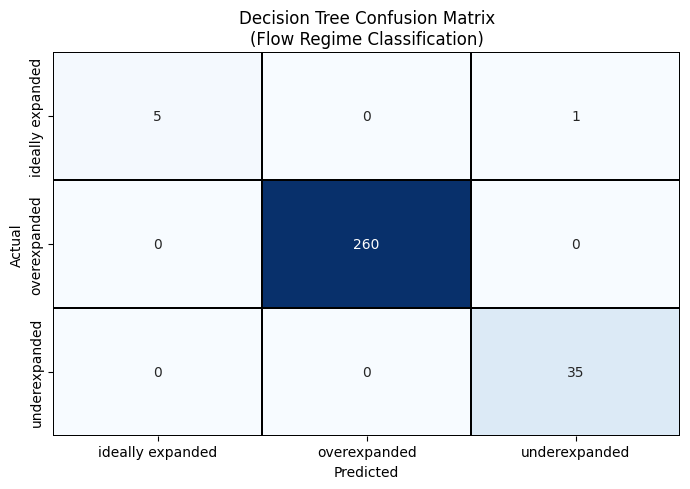

In [ ]:
# Model performance
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

# Use numeric labels for encoded data
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1, 2]   # encoded class values
)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cbar=False,
    linewidths=0.1,
    linecolor="black"
)
plt.title("Decision Tree Confusion Matrix\n(Flow Regime Classification)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

The confusion matrix shows that the decision tree classifier performs exceptionally well in identifying nozzle flow regimes. Underexpanded and overexpanded flows are classified with 100% accuracy. The model only misclassified a single ideally expanded case as underexpanded, which is expected given the small size of the ideal class and the narrow NPR tolerance defining this regime. These results demonstrate that the physics-derived features (area ratios, estimated Mach number, and nozzle pressure ratios) enable clear separation of flow regimes, and the model effectively captures the underlying compressible-flow behavior.

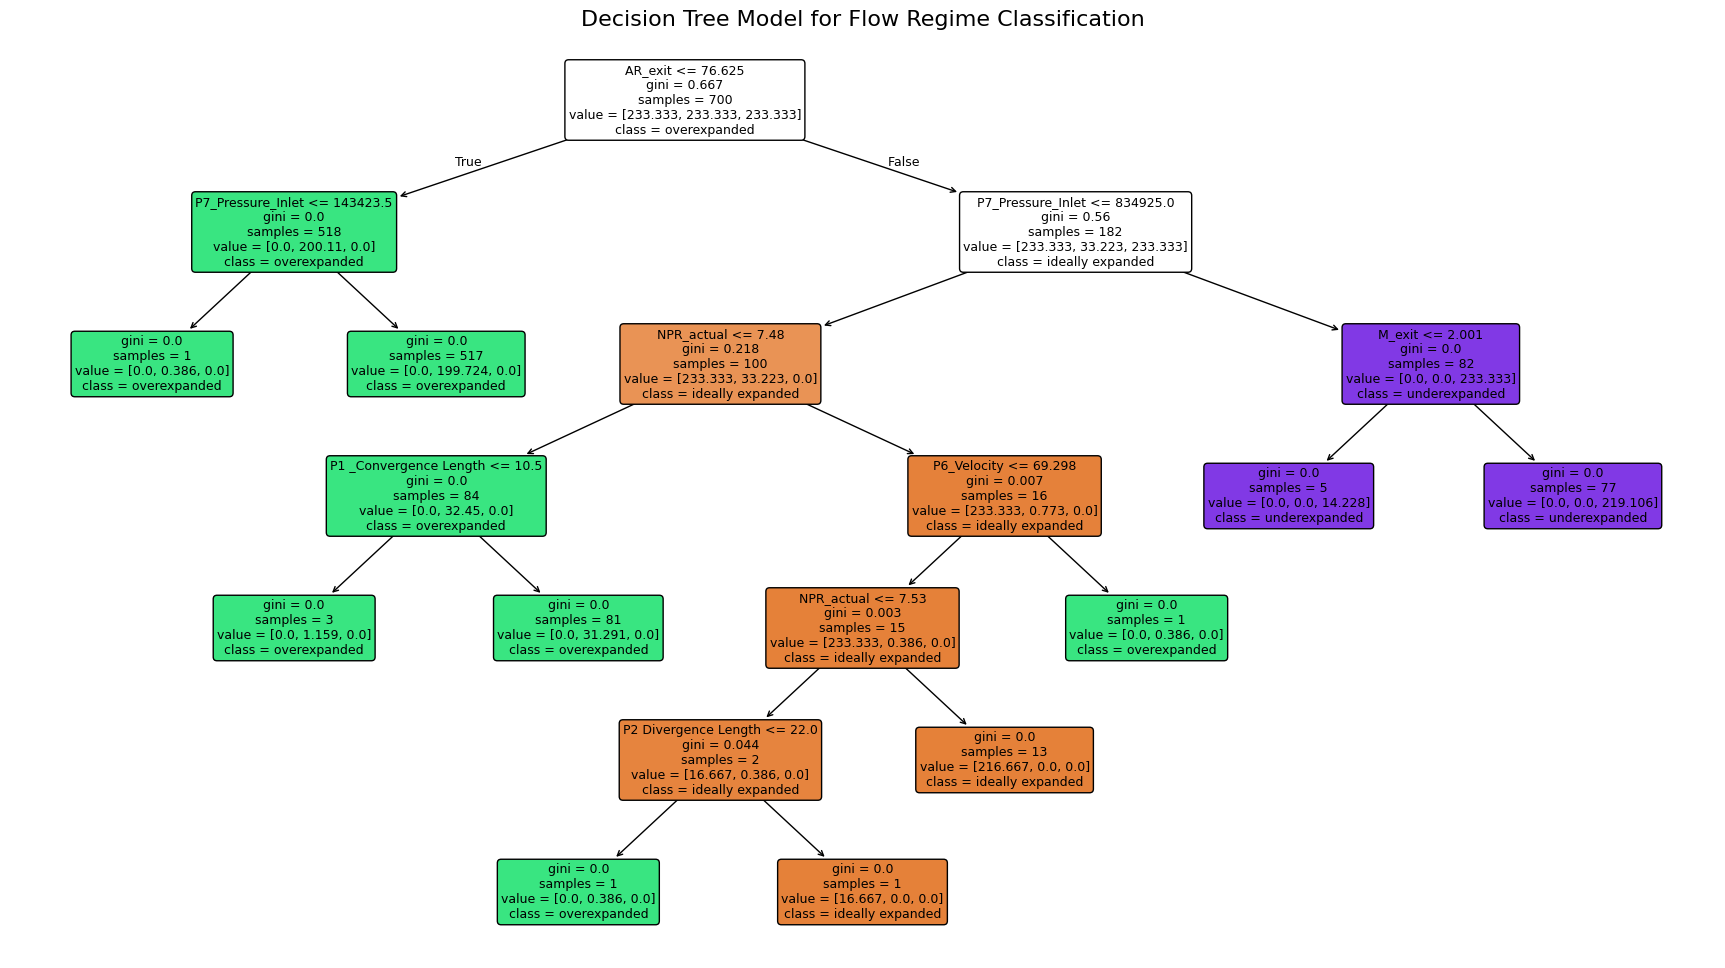

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))

tree.plot_tree(
    dtree,
    feature_names=feature_cols,
    class_names=encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Model for Flow Regime Classification", fontsize=16)
plt.show()

The decision tree classifier provides a physically interpretable mapping between nozzle operating conditions and the resulting jet expansion regime (overexpanded, ideally expanded, or underexpanded). The structure of the tree reflects fundamental compressible-flow relationships, particularly the dependence of jet expansion behavior on geometry, pressure ratios, and exit Mach number.

Essentially, the decision tree effectively performs a hierarchy of physics-driven decisions:
1. Global geometric capability (AR_exit) determines whether the nozzle can expand the jet sufficiently.
2. Operating pressure ratio (NPR_actual) determines whether the actual operating conditions match the nozzle's design expansion level.
3. Local geometric and velocity effects refine the identification of ideal flow regions.
4. Exit Mach number cleanly distinguishes high-energy underexpanded jets.

This alignment between machine learning logic and classical fluid-dynamics theory validates both the quality of the dataset and the interpretable performance of the decision tree model.

### pruning tree - one (cost-complexity)

In [ ]:
path = dtree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print("Number of candidate alphas:", len(ccp_alphas))

Number of candidate alphas: 8


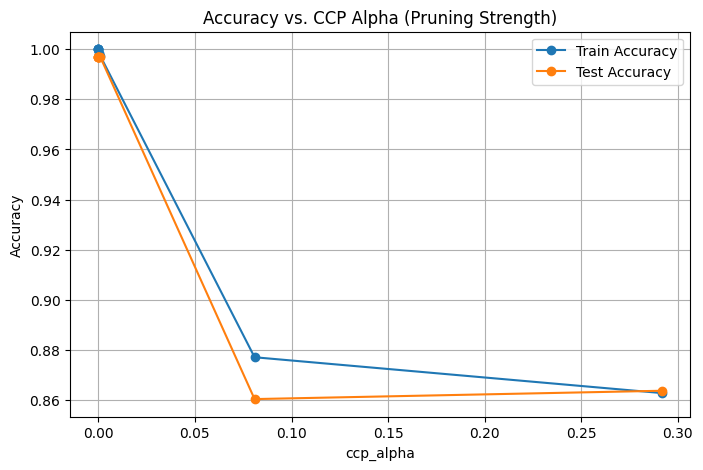

Best alpha: 0.0


In [ ]:
# train a pruned tree for each alpha
pruned_trees = []
for ccp in ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        ccp_alpha=ccp
    )
    model.fit(X_train, y_train)
    pruned_trees.append(model)

# evaluate all pruned trees on validation split
train_scores = [model.score(X_train, y_train) for model in pruned_trees]
test_scores  = [model.score(X_test, y_test) for model in pruned_trees]

# plot accuracy vs alpha
plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, train_scores, marker="o", label="Train Accuracy")
plt.plot(ccp_alphas, test_scores, marker="o", label="Test Accuracy")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. CCP Alpha (Pruning Strength)")
plt.legend()
plt.grid(True)
plt.show()

# selecting best alpha (max test accuracy)
best_alpha = ccp_alphas[np.argmax(test_scores)]
print("Best alpha:", best_alpha)

In [ ]:
# train final pruned tree
pruned_tree = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    ccp_alpha=best_alpha
)
pruned_tree.fit(X_train, y_train)

print("\nPruned Tree Test Accuracy:", pruned_tree.score(X_test, y_test))


Pruned Tree Test Accuracy: 0.9966777408637874


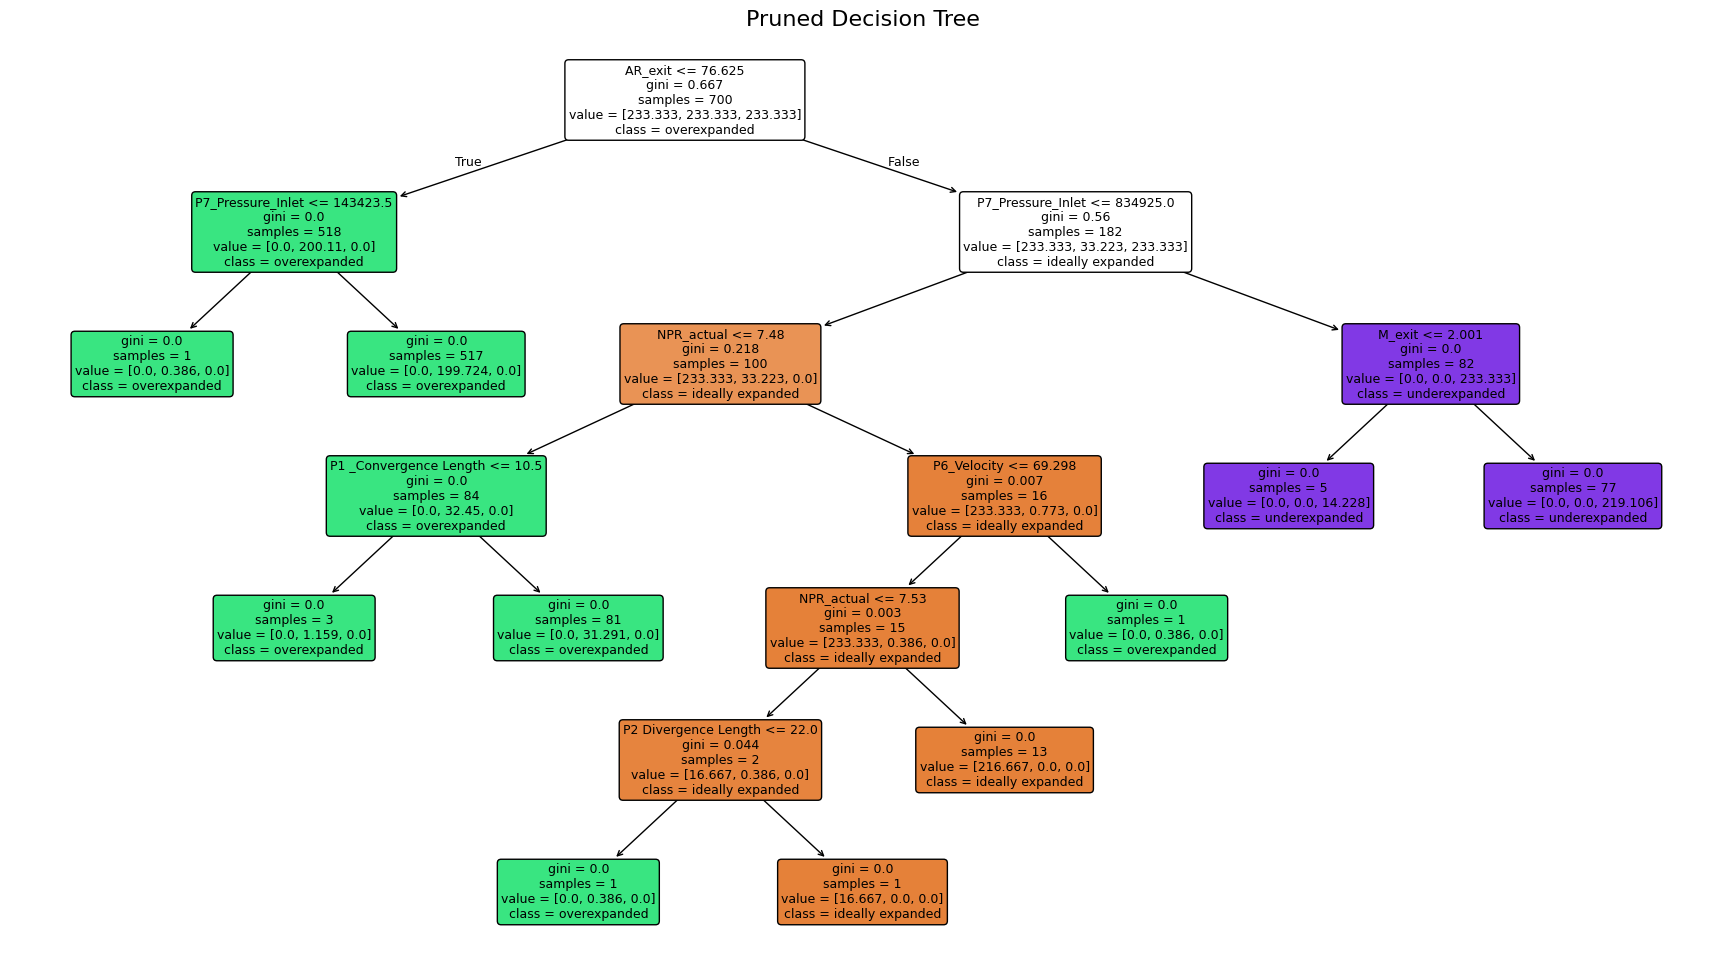

In [ ]:
plt.figure(figsize=(22, 12))
tree.plot_tree(
    pruned_tree,
    feature_names=feature_cols,
    class_names=encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Pruned Decision Tree", fontsize=16)
plt.show()

In [ ]:
print("Original Data")
print("Original depth:", dtree.get_depth())
print("Original leaves:", dtree.get_n_leaves())
print()
print("Pruned Data")
print("Best alpha:", best_alpha)
print("Pruned depth:", pruned_tree.get_depth())
print("Pruned leaves:", pruned_tree.get_n_leaves())

Original Data
Original depth: 6
Original leaves: 10

Pruned Data
Best alpha: 0.0
Pruned depth: 6
Pruned leaves: 10


Pruning tells us that when alpha = 0, the decision tree has the best accuracy. This means that no pruning improves the test accuracy, so the Decision Tree is ideal as is, not overfitting the data.

### pruning tree - two (pre-pruning & light post pruning)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "max_depth": [3, 4, 5, 6],
    "min_samples_leaf": [3, 5, 8, 12],
    "min_samples_split": [10, 20],
}

dtree2 = DecisionTreeClassifier(class_weight="balanced", random_state=42)

grid = GridSearchCV(
    dtree2,
    param_grid,
    scoring="accuracy",
    cv=5
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best parameters: {'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 10}
Best CV accuracy: 0.99


In [ ]:
best_params = grid.best_params_

pruned_tree2 = DecisionTreeClassifier(
    **best_params,
    class_weight="balanced",
    random_state=42
)

pruned_tree2.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=3, min_samples_leaf=3,
                       min_samples_split=10, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_pruned2 = pruned_tree2.predict(X_test)

print("Accuracy (Test):", accuracy_score(y_test, y_pred_pruned2))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pruned2))

Accuracy (Test): 0.9966777408637874

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      1.00      1.00       260
           2       0.97      1.00      0.99        35

    accuracy                           1.00       301
   macro avg       0.99      0.94      0.97       301
weighted avg       1.00      1.00      1.00       301



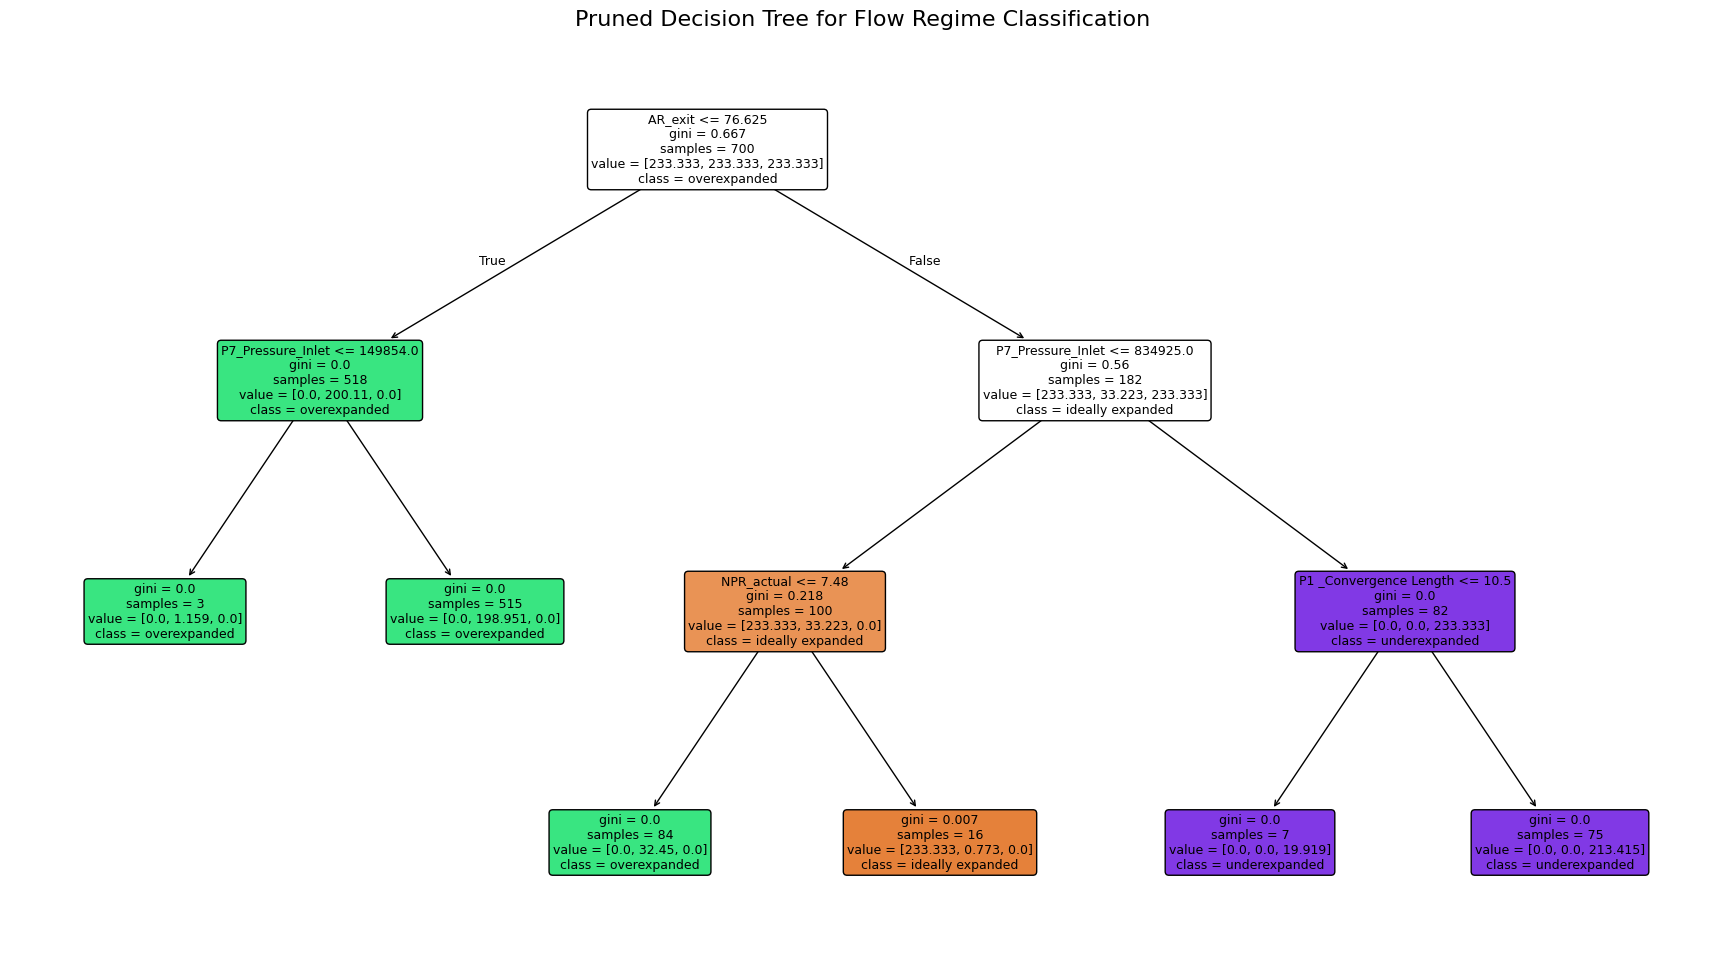

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))
tree.plot_tree(
    pruned_tree2,
    feature_names=feature_cols,
    class_names=encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Pruned Decision Tree for Flow Regime Classification", fontsize=16)
plt.show()

comparing the accuracies:

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# this cell somtimes gives an error; just rerun the cell within the corrected method
# that performs dtree.fit independently, then rerun this cell, and it will work
# if errror does not occur, code is running as expected

# Predictions
y_pred_unpruned = dtree.predict(X_test)
y_pred_pruned2 = pruned_tree2.predict(X_test)

# Accuracies
acc_unpruned = accuracy_score(y_test, y_pred_unpruned)
acc_pruned = accuracy_score(y_test, y_pred_pruned2)

print("Accuracy Comparison")
print(f"Unpruned Tree Accuracy: {acc_unpruned:.4f}")
print(f"Pruned Tree Accuracy:   {acc_pruned:.4f}")

print("\nUnpruned Classification Report")
print(classification_report(y_test, y_pred_unpruned))

print("\nPruned Classification Report")
print(classification_report(y_test, y_pred_pruned2))


Accuracy Comparison
Unpruned Tree Accuracy: 0.9967
Pruned Tree Accuracy:   0.9967

Unpruned Classification Report
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      1.00      1.00       260
           2       0.97      1.00      0.99        35

    accuracy                           1.00       301
   macro avg       0.99      0.94      0.97       301
weighted avg       1.00      1.00      1.00       301


Pruned Classification Report
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      1.00      1.00       260
           2       0.97      1.00      0.99        35

    accuracy                           1.00       301
   macro avg       0.99      0.94      0.97       301
weighted avg       1.00      1.00      1.00       301



### original code - no longer relevant, but helpful for comprehension

assisted in determining need for change in physics compressible flow approach to create everything in the corrected method portion.

In [ ]:
import numpy as np
import pandas as pd

# constants
gamma = 1.4
P_ambient = 101325  # Pa


# compute areas
df['A_inlet'] = np.pi * (df['P3_InletDiameter']**2) / 4
df['A_throat'] = np.pi * (df['P4_Throttle_Diameter']**2) / 4
df['A_exit'] = np.pi * (df['P5_ExitDiameter']**2) / 4


# area ratios
df['CR_inlet_to_throat'] = df['A_inlet'] / df['A_throat']
df['ER_throat_to_exit'] = df['A_exit'] / df['A_throat']


# invert area-mach for exit Mach
def area_mach_relation(M, gamma=1.4):
    """ Isentropic area-Mach relation A/A* for given Mach number M """
    term1 = 1/M
    term2 = ((2/(gamma+1)) * (1 + (gamma-1)/2 * M**2))**((gamma+1)/(2*(gamma-1)))
    return term1 * term2

def solve_exit_mach(area_ratio, gamma=1.4):
    """
    Numerically solve for exit Mach given A_exit/A_throat.
    We assume supersonic flow in a diverging nozzle.
    """
    # Search Mach range for supersonic solutions
    M_vals = np.linspace(1.0, 10.0, 5000)
    A_vals = area_mach_relation(M_vals, gamma)

    idx = (np.abs(A_vals - area_ratio)).argmin()
    return M_vals[idx]

df['M_exit_estimated'] = df['ER_throat_to_exit'].apply(solve_exit_mach)

# exit static pressure
def isentropic_pressure(P0, M, gamma=1.4):
    return P0 * (1 + (gamma - 1)/2 * M**2)**(-gamma/(gamma-1))

df['P_exit_estimated'] = isentropic_pressure(
    df['P7_Pressure_Inlet'],
    df['M_exit_estimated']
)

# classifying flow regime
def classify_regime(P_exit, P_ambient=101325):
    if P_exit > P_ambient * 1.05:
        return "underexpanded"
    elif P_exit < P_ambient * 0.95:
        return "overexpanded"
    else:
        return "ideally_expanded"

df['FlowRegime'] = df['P_exit_estimated'].apply(classify_regime)

print("Physics-based features appended successfully!")
df.head()

Physics-based features appended successfully!


,Name,P1 _Convergence Length,P2 Divergence Length,P3_InletDiameter,P4_Throttle_Diameter,P5_ExitDiameter,P7_Pressure_Inlet,P6_Velocity,A_inlet,A_throat,A_exit,CR_inlet_to_throat,ER_throat_to_exit,M_exit_estimated,P_exit_estimated,FlowRegime
0,DP 0,15,15,12,3,15,1378950,119.130700,113.097336,7.068583,176.714587,16.000000,25.000000,5.000400,2605.052241,overexpanded
1,DP 1,28,30,21,1,9,474973,25.174023,346.360590,0.785398,63.617251,441.000000,81.000000,6.613523,164.250117,overexpanded
2,DP 2,19,17,13,3,20,1285097,97.235954,132.732290,7.068583,314.159265,18.777778,44.444444,5.751150,1054.537750,overexpanded
3,DP 3,20,24,19,1,23,382353,28.955469,283.528737,0.785398,415.475628,361.000000,529.000000,9.972995,9.173296,overexpanded
4,DP 4,13,14,11,3,13,822234,130.119600,95.033178,7.068583,132.732290,13.444444,18.777778,4.649330,2362.519338,overexpanded


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# encode target labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Label mapping:")
for cls, code in zip(encoder.classes_, encoder.transform(encoder.classes_)):
    print(f"{cls} → {code}")

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)



Label mapping:
overexpanded → 0


In [ ]:
# select features and target
feature_cols = [
    'P1 _Convergence Length',
    'P2 Divergence Length',
    'P3_InletDiameter',
    'P4_Throttle_Diameter',
    'P5_ExitDiameter',
    'P6_Velocity',
    'P7_Pressure_Inlet',
    'CR_inlet_to_throat',
    'ER_throat_to_exit',
    'M_exit_estimated',
    'P_exit_estimated'
]

X = df[feature_cols]
y = df['FlowRegime']

KeyError: "['CR_inlet_to_throat', 'ER_throat_to_exit', 'M_exit_estimated', 'P_exit_estimated'] not in index"

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# train decision tree
clf = DecisionTreeClassifier(max_depth=6, random_state=42)
clf.fit(X_train, y_train)

# predictions & evaluation
y_pred = clf.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
 [[301]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       301

    accuracy                           1.00       301
   macro avg       1.00      1.00      1.00       301
weighted avg       1.00      1.00      1.00       301



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


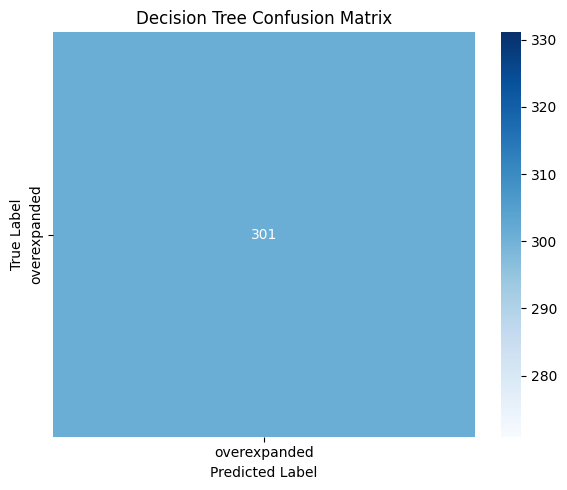

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create labeled categories (using the original encoder)
labels = encoder.classes_

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
print(df[['P_exit_estimated', 'FlowRegime']].head())
print(df['FlowRegime'].value_counts())


   P_exit_estimated    FlowRegime
0       2605.052241  overexpanded
1        164.250117  overexpanded
2       1054.537750  overexpanded
3          9.173296  overexpanded
4       2362.519338  overexpanded
FlowRegime
overexpanded    1001
Name: count, dtype: int64


everything ended up being overexpanded, so went to review math since this likely shouldn't be the case. altered the code and mathematical approach to change.

## Part 2: Random Forest Utilization for Classifying Flow Regime

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# train and predict
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

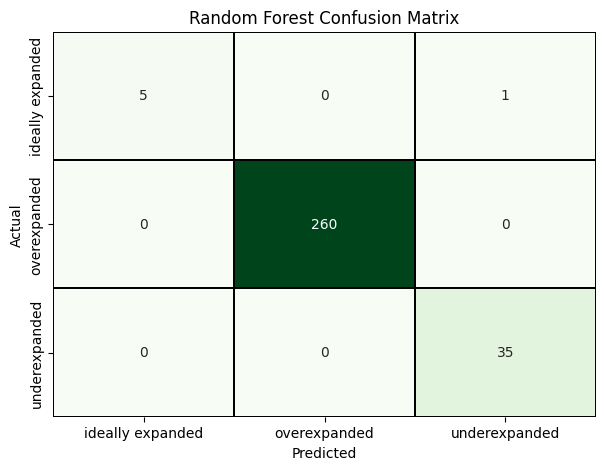

In [ ]:
# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    rf_cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    linewidths=0.2, linecolor="black", cbar=False
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9966777408637874

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      1.00      1.00       260
           2       0.97      1.00      0.99        35

    accuracy                           1.00       301
   macro avg       0.99      0.94      0.97       301
weighted avg       1.00      1.00      1.00       301



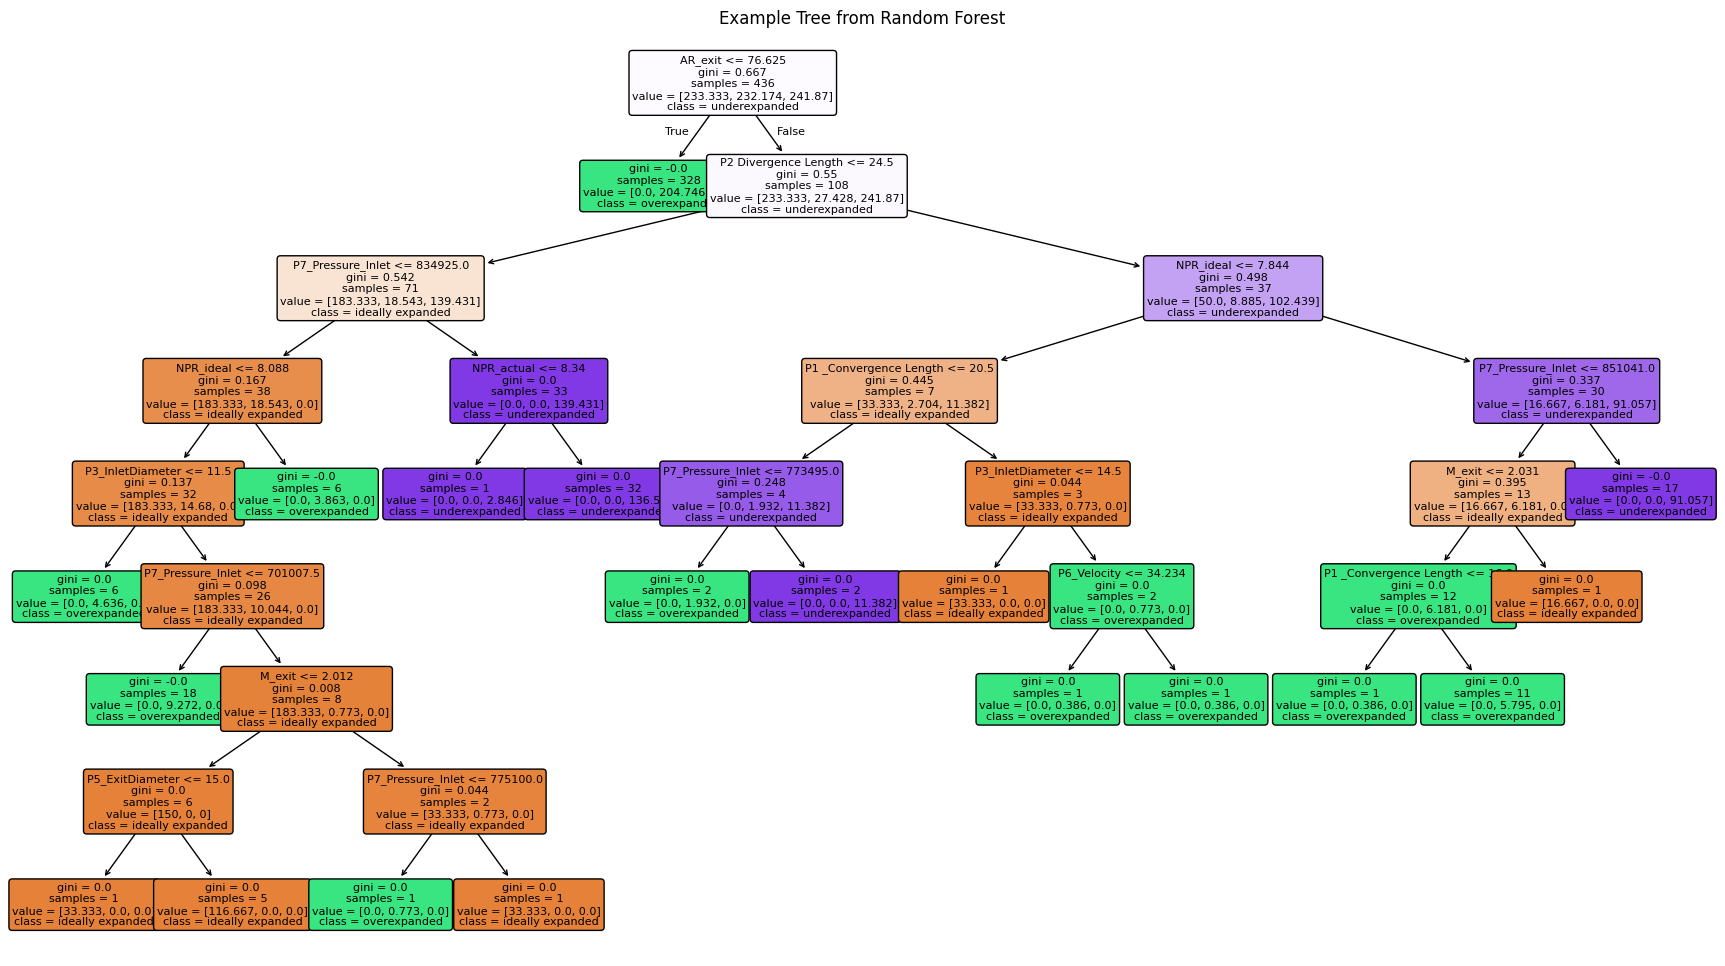

In [ ]:
# plotting single tree

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

estimator = rf.estimators_[3]  # can change this for any index

plt.figure(figsize=(22, 12))
plot_tree(
    estimator,
    feature_names=feature_cols,
    class_names=encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Example Tree from Random Forest")
plt.show()

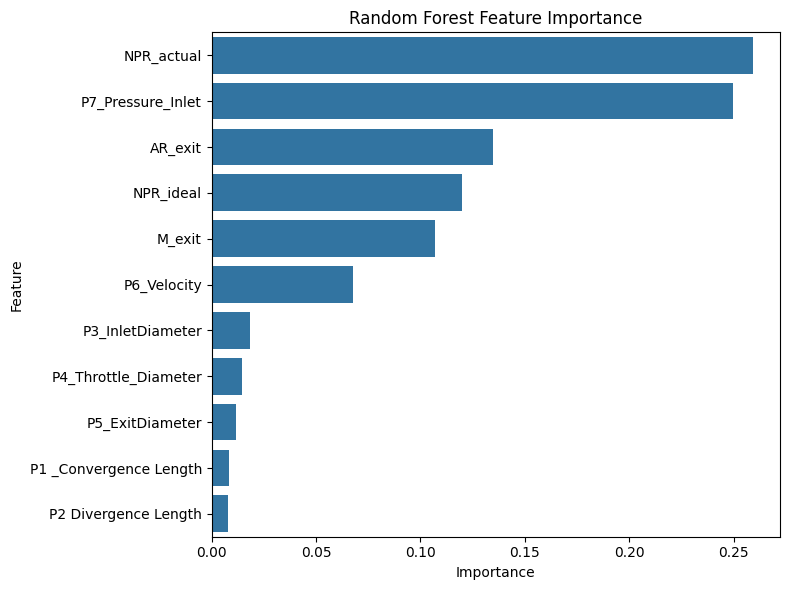

In [ ]:
# feature importance

import seaborn as sns
import matplotlib.pyplot as plt

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,6))
sns.barplot(
    x=importances[indices],
    y=np.array(feature_cols)[indices]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Part 3: MLP (Neural Network) for Classifying Flow Regime

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [ ]:
# reproducibility
RNG_SEED = 42
np.random.seed(RNG_SEED)
random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RNG_SEED)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
# preparing data, scale
scaler = StandardScaler()
X_train_np = np.array(X_train)  # ensure numpy not int
X_test_np  = np.array(X_test)

# fit scaler on training data
scaler.fit(X_train_np)
X_train_scaled = scaler.transform(X_train_np)
X_test_scaled  = scaler.transform(X_test_np)

# labels as np
y_train_np = np.array(y_train).astype(np.int64)
y_test_np  = np.array(y_test).astype(np.int64)

In [ ]:
# datasets and dataloaders
batch_size = 32

train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train_np, dtype=torch.long)
)

# validation split from training set
val_frac = 0.15
val_size = int(len(train_dataset) * val_frac)
train_size = len(train_dataset) - val_size
train_ds, val_ds = random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(RNG_SEED))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32),
                                        torch.tensor(y_test_np, dtype=torch.long)),
                          batch_size=batch_size, shuffle=False)

In [ ]:
# building model

input_dim = X_train_scaled.shape[1]
n_classes = len(encoder.classes_)

class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=[128,64], dropout=0.2):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

model = MLP(input_dim, n_classes, hidden=[128,64], dropout=0.2).to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [ ]:
# loss, optimizer, and scheduler

criterion = nn.CrossEntropyLoss()   # expects raw logits
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=6)

In [ ]:
# training loop with early stopping

n_epochs = 200
patience = 15
best_val_loss = np.inf
epochs_no_improve = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(1, n_epochs+1):
    # training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in train_loader:
        xb = xb.to(device); yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    train_loss = running_loss / total
    train_acc = correct / total

    # validation
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device); yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    val_loss = running_loss / total
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    # early stopping check
    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = {k: v.cpu() for k,v in model.state_dict().items()}
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")

    if epochs_no_improve >= patience:
        print(f"Stopping early at epoch {epoch} (no improvement in {patience} epochs).")
        break

# load best model state
model.load_state_dict(best_state)

Epoch 001 | train_loss=0.9218 acc=0.6218 | val_loss=0.7878 acc=0.8190
Epoch 010 | train_loss=0.1248 acc=0.9748 | val_loss=0.1235 acc=0.9810
Epoch 020 | train_loss=0.0796 acc=0.9748 | val_loss=0.0743 acc=0.9714
Epoch 030 | train_loss=0.0356 acc=0.9866 | val_loss=0.0929 acc=0.9619
Epoch 040 | train_loss=0.0218 acc=0.9966 | val_loss=0.0638 acc=0.9714
Epoch 050 | train_loss=0.0282 acc=0.9933 | val_loss=0.0633 acc=0.9810
Epoch 060 | train_loss=0.0181 acc=0.9966 | val_loss=0.0685 acc=0.9714
Stopping early at epoch 60 (no improvement in 15 epochs).


<All keys matched successfully>

In [ ]:
# test set evaluation

model.eval()
all_preds = []
all_trues = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_trues.append(yb.numpy())
all_preds = np.concatenate(all_preds)
all_trues = np.concatenate(all_trues)

print("\nTest Accuracy (NN):", accuracy_score(all_trues, all_preds))
print("\nClassification Report (NN):")
print(classification_report(all_trues, all_preds, target_names=encoder.classes_))


Test Accuracy (NN): 0.9767441860465116

Classification Report (NN):
                  precision    recall  f1-score   support

ideally expanded       0.33      0.17      0.22         6
    overexpanded       0.98      1.00      0.99       260
   underexpanded       0.97      0.97      0.97        35

        accuracy                           0.98       301
       macro avg       0.76      0.71      0.73       301
    weighted avg       0.97      0.98      0.97       301



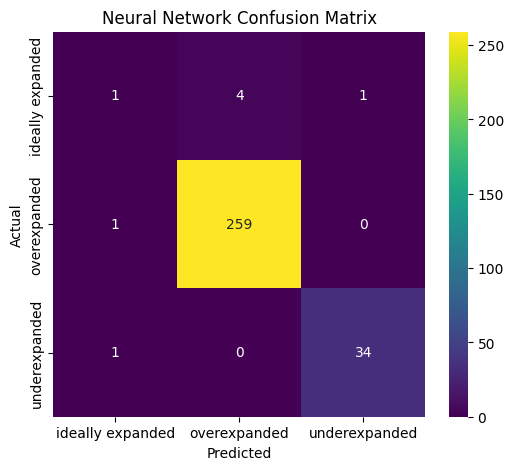

In [ ]:
# plotting confusion matrix

cm = confusion_matrix(all_trues, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

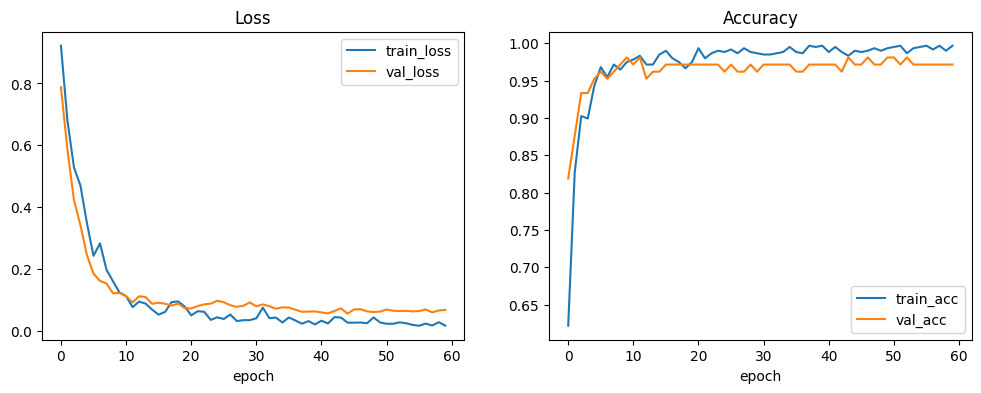

In [ ]:
# training curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.legend(); plt.xlabel('epoch'); plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(train_accs, label='train_acc')
plt.plot(val_accs, label='val_acc')
plt.legend(); plt.xlabel('epoch'); plt.title('Accuracy')
plt.show()

## Summary of Classification Strategies

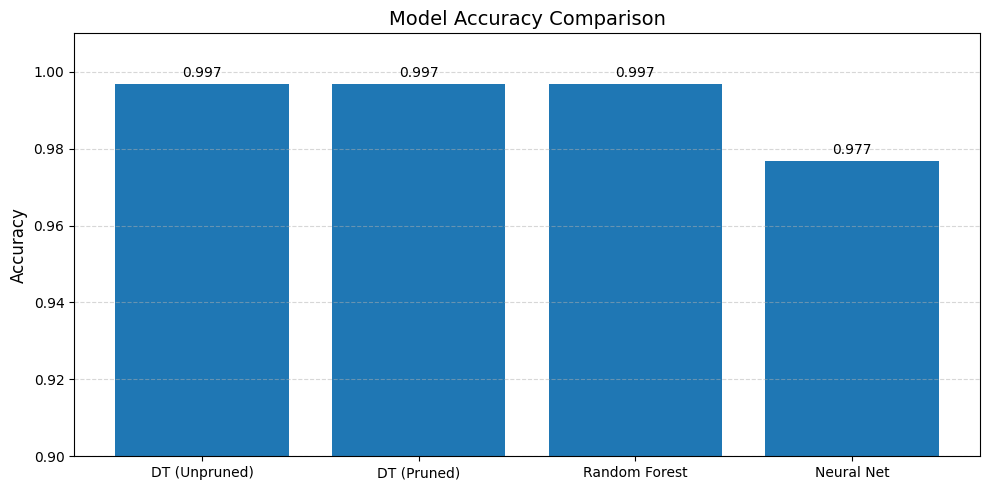

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# accuracy values summarized
acc_dt       = 0.9967   # unpruned Decision Tree
acc_dt_prune = 0.9967   # pruned Decision Tree (for both methods)
acc_rf       = 0.9967   # Random Forest
acc_nn       = 0.9767   # Neural Network (MLP)

models = ["DT (Unpruned)", "DT (Pruned)", "Random Forest", "Neural Net"]
accuracies = [acc_dt, acc_dt_prune, acc_rf, acc_nn]

# plot
plt.figure(figsize=(10, 5))
bars = plt.bar(models, accuracies)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.3f}",
        ha='center',
        fontsize=10
    )

plt.ylim(0.90, 1.01)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Model Accuracy Comparison", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Part 4: Determining Shock Location

In [ ]:
import pandas as pd
import numpy as np

# load dataset
df2 = pd.read_csv("/content/sample_data/Data2.csv")

print("Dataset loaded successfully.")
print("Shape:", df2.shape)
print("\nPreview:")
df2.head()

Dataset loaded successfully.
Shape: (1001, 8)

Preview:


,Name,P1 _Convergence Length,P2 Divergence Length,P3_InletDiameter,P4_Throttle_Diameter,P5_ExitDiameter,P7_Pressure_Inlet,P6_Velocity
0,DP 0,15,15,12,3,15,1378950,119.130700
1,DP 1,28,30,21,1,9,474973,25.174023
2,DP 2,19,17,13,3,20,1285097,97.235954
3,DP 3,20,24,19,1,23,382353,28.955469
4,DP 4,13,14,11,3,13,822234,130.119600


applying physics below

In [ ]:
import numpy as np
from scipy.optimize import fsolve

gamma = 1.4
P_ambient = 101325  # atmospheric pressure in Pa

In [ ]:
# area mach relations

def area_mach_relation(M, AR, gamma=1.4):
    """Isentropic area-Mach relation set equal to AR."""
    return ((((2/(gamma+1)) * (1 + (gamma-1)/2 * M**2)))**((gamma+1)/(2*(gamma-1))) / M) - AR

def solve_mach(AR, supersonic=True):
    """Return Mach solution for given area ratio AR = A/A_throat.
       Use supersonic branch by default for divergent region."""
    try:
        M_guess = 2.0 if supersonic else 0.2
        M_solution = fsolve(area_mach_relation, M_guess, args=(AR,), maxfev=200)
        M = float(M_solution[0])
        if M <= 0 or np.isnan(M):
            return None
        return M
    except Exception:
        return None

# geometric areas
A_throat = (np.pi / 4) * (df2["P4_Throttle_Diameter"]**2)
A_exit   = (np.pi / 4) * (df2["P5_ExitDiameter"]**2)

df2["AR_exit"] = A_exit / A_throat

# solve exit mach
df2["M_exit"] = df2["AR_exit"].apply(lambda AR: solve_mach(AR, supersonic=True))

# ideal and actual NPRs
df2["NPR_ideal"] = (1 + (gamma-1)/2 * df2["M_exit"]**2)**(gamma/(gamma-1))
df2["NPR_actual"] = df2["P7_Pressure_Inlet"] / P_ambient

# flow regime
def classify_regime(row, epsilon=0.05):
    NPR_a = row["NPR_actual"]
    NPR_i = row["NPR_ideal"]

    if NPR_a > NPR_i * (1 + epsilon):
        return "underexpanded"
    elif NPR_a < NPR_i * (1 - epsilon):
        return "overexpanded"
    else:
        return "ideally expanded"

df2["FlowRegime"] = df2.apply(classify_regime, axis=1)

print("Physics-based features added.")
df2.head()

/tmp/ipython-input-1669996518.py:12: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  M_solution = fsolve(area_mach_relation, M_guess, args=(AR,), maxfev=200)


Physics-based features added.


,Name,P1 _Convergence Length,P2 Divergence Length,P3_InletDiameter,P4_Throttle_Diameter,P5_ExitDiameter,P7_Pressure_Inlet,P6_Velocity,AR_exit,M_exit,NPR_ideal,NPR_actual,FlowRegime,NPR_ratio,nozzle_length,dM_dx,Shock_Likely
0,DP 0,15,15,12,3,15,1378950,119.130700,25.000000,5.000000,529.089784,13.609178,overexpanded,0.025722,30,0.166667,1
1,DP 1,28,30,21,1,9,474973,25.174023,81.000000,2.044608,8.387339,4.687619,overexpanded,0.558892,58,0.035252,1
2,DP 2,19,17,13,3,20,1285097,97.235954,44.444444,5.751406,1218.964608,12.682921,overexpanded,0.010405,36,0.159761,1
3,DP 3,20,24,19,1,23,382353,28.955469,529.000000,2.002133,7.850453,3.773531,overexpanded,0.480677,44,0.045503,1
4,DP 4,13,14,11,3,13,822234,130.119600,18.777778,4.649459,348.087781,8.114819,overexpanded,0.023313,27,0.172202,1


features being added to aid in shock indication

In [ ]:
# pressure ratio: actual vs ideal
df2["NPR_ratio"] = df2["NPR_actual"] / df2["NPR_ideal"]

# Mach number gradient approximation along nozzle length
# using convergence + divergence lengths as proxy for x
df2["nozzle_length"] = df2["P1 _Convergence Length"] + df2["P2 Divergence Length"]
df2["dM_dx"] = df2["M_exit"] / df2["nozzle_length"]  # rough estimate

# shock likely if overexpanded and Mach drop is significant
# use heuristic: dM/dx > threshold or NPR_ratio < 0.9
df2["Shock_Likely"] = np.where(
    (df2["FlowRegime"] == "overexpanded") &
    ((df2["dM_dx"] > 0.5) | (df2["NPR_ratio"] < 0.9)),
    1, 0
)

print("Shock features added.")
df2[["FlowRegime", "NPR_ratio", "dM_dx", "Shock_Likely"]].head(10)

Shock features added.


,FlowRegime,NPR_ratio,dM_dx,Shock_Likely
0,overexpanded,0.025722,0.166667,1
1,overexpanded,0.558892,0.035252,1
2,overexpanded,0.010405,0.159761,1
3,overexpanded,0.480677,0.045503,1
4,overexpanded,0.023313,0.172202,1
5,overexpanded,0.004245,0.091959,1
6,overexpanded,0.012087,0.175390,1
7,overexpanded,0.790342,0.083400,1
8,overexpanded,0.029670,0.118514,1
9,overexpanded,0.306757,0.058804,1


### Original binary shock prediction with random tree

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# use geometry, Mach, velocity, NPR, and Mach gradient as features
feature_cols = [
    "P1 _Convergence Length",
    "P2 Divergence Length",
    "P3_InletDiameter",
    "P4_Throttle_Diameter",
    "P5_ExitDiameter",
    "P6_Velocity",
    "P7_Pressure_Inlet",
    "AR_exit",
    "M_exit",
    "NPR_actual",
    "NPR_ideal",
    "NPR_ratio",
    "dM_dx"
]

X = df2[feature_cols]
y = df2["Shock_Likely"]


# splitting train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train/Test split complete.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training label distribution:\n", y_train.value_counts())
print("Testing label distribution:\n", y_test.value_counts())

Train/Test split complete.
Training samples: 700
Testing samples: 301
Training label distribution:
 Shock_Likely
1    601
0     99
Name: count, dtype: int64
Testing label distribution:
 Shock_Likely
1    258
0     43
Name: count, dtype: int64


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',  # handle class imbalance
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("\nRandom Forest Accuracy:", acc)

# classification report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred))


Random Forest Accuracy: 1.0

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00       258

    accuracy                           1.00       301
   macro avg       1.00      1.00      1.00       301
weighted avg       1.00      1.00      1.00       301



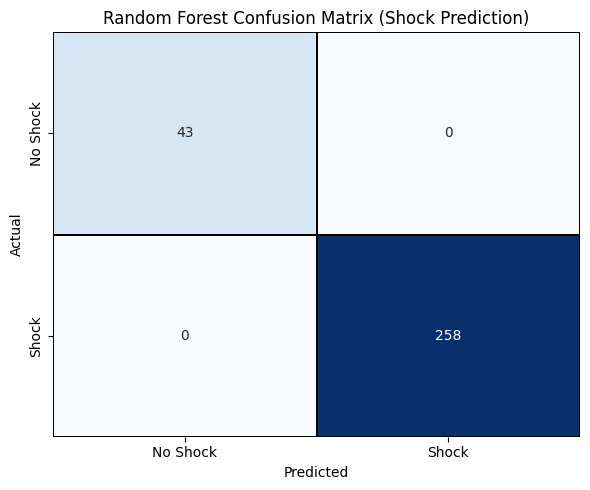

In [ ]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Shock", "Shock"],
            yticklabels=["No Shock", "Shock"],
            cbar=False, linewidths=0.1, linecolor='black')
plt.title("Random Forest Confusion Matrix (Shock Prediction)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

/tmp/ipython-input-3598234779.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette="viridis")


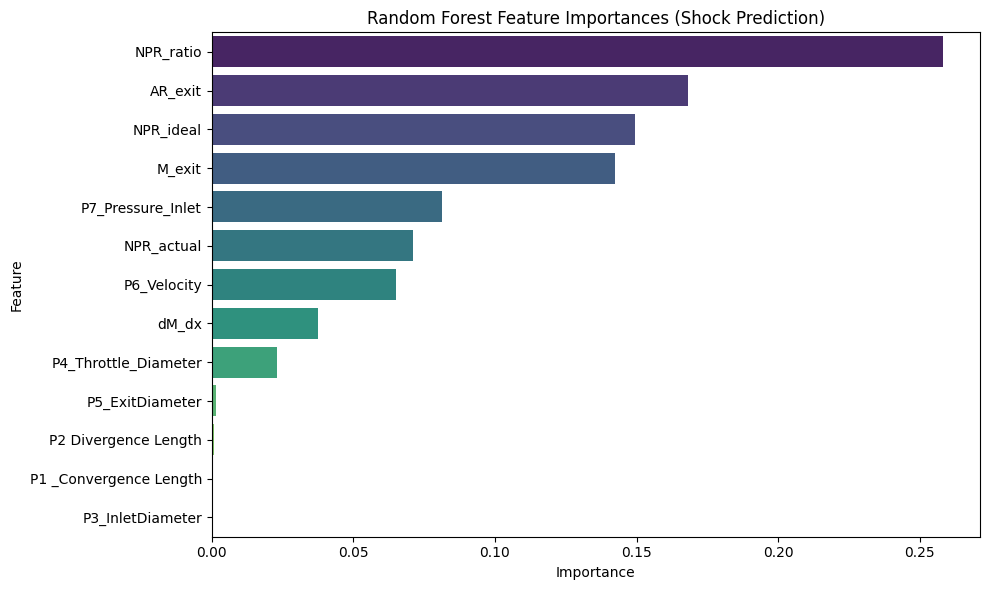

In [ ]:
# feature importance

importances = rf.feature_importances_
feat_importance = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette="viridis")
plt.title("Random Forest Feature Importances (Shock Prediction)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Adjusted binary shock prediction

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
from scipy.optimize import fsolve
import tqdm

gamma = 1.4
P_ambient = 101325.0  # Pa, ambient/back pressure

def area_mach_relation(M, AR, gamma=1.4):
    return ((((2/(gamma+1)) * (1 + (gamma-1)/2 * M**2)))**((gamma+1)/(2*(gamma-1))) / M) - AR

def solve_mach(AR, supersonic=True):
    """Return Mach solution for given area ratio AR = A/A_throat.
       Use supersonic branch by default for divergent region."""
    try:
        M_guess = 2.0 if supersonic else 0.2
        M_solution = fsolve(area_mach_relation, M_guess, args=(AR,), maxfev=200)
        M = float(M_solution[0])
        if M <= 0 or np.isnan(M):
            return None
        return M
    except Exception:
        return None

def compute_shock_info_for_row(row, n_stations=60):
    """Given a dataframe row, compute whether an internal normal shock is feasible,
       and if so, return the axial normalized location x/L (0=throat, 1=exit) of the first station
       where the post-shock static pressure p2 >= ambient. Otherwise return None."""
    # Required inputs from row:
    # throat & exit diameters (P4_Throttle_Diameter, P5_ExitDiameter)
    # divergence length (P2 Divergence Length)
    # inlet stagnation pressure (P7_Pressure_Inlet)  (assume this is total/stagnation pressure)
    try:
        D_throat = float(row["P4_Throttle_Diameter"])
        D_exit   = float(row["P5_ExitDiameter"])
        L_div    = float(row["P2 Divergence Length"])
        P0       = float(row["P7_Pressure_Inlet"])
    except Exception:
        return {"shock_present": 0, "shock_x_norm": np.nan}
    if L_div <= 0:
        return {"shock_present": 0, "shock_x_norm": np.nan}

    # compute areas
    A_throat = np.pi/4 * (D_throat**2)
    A_exit   = np.pi/4 * (D_exit**2)

    # discretize axial stations along divergent section from throat (x=0) to exit (x=L_div)
    xs = np.linspace(0, L_div, n_stations)

    # assume linear increase in diameter (hence area)
    Ds = D_throat + (D_exit - D_throat) * (xs / L_div)
    As = np.pi/4 * (Ds**2)
    ARs = As / A_throat  # local area ratio A(x)/A_throat

    # compute supersonic Mach (if AR >= 1) else use subsonic branch
    for i, AR in enumerate(ARs):
        if AR <= 0:
            continue
        # choose supersonic branch in diverging section; but if AR < 1 use subsonic (just in case)
        sup = True if AR >= 1.0 else False
        M1 = solve_mach(AR, supersonic=sup)
        if M1 is None or M1 <= 1.0:  # normal shock requires M1>1
            continue

        # local static pressure p1 from stagnation P0 and Mach M1 (isentropic)
        p1 = P0 / ((1 + (gamma - 1)/2 * M1**2)**(gamma/(gamma - 1)))

        # compute post-normal-shock static pressure p2 using normal-shock relation:
        # p2/p1 = 1 + (2*gamma/(gamma+1))*(M1^2 - 1)
        p2 = p1 * (1 + (2*gamma/(gamma+1)) * (M1**2 - 1))

        # if p2 >= ambient, a normal shock at this station can produce (or exceed) ambient pressure.
        # consider this a feasible internal shock location.
        if p2 >= P_ambient:
            x_norm = xs[i] / L_div  # normalized location in [0,1]
            return {"shock_present": 1, "shock_x_norm": x_norm}

    # no feasible internal normal shock found by this test
    return {"shock_present": 0, "shock_x_norm": np.nan}


# apply the function to the whole dataframe
shock_present_list = []
shock_x_list = []

# use tqdm for progress (otherwise just a simple loop)
use_tqdm = True
iter_rows = df2.itertuples(index=False)  # faster than iterrows
if use_tqdm:
    try:
        from tqdm import tqdm as _tqdm
        iter_rows = _tqdm(list(df2.itertuples(index=False)), desc="Computing shock feasibility")
        # but we need index access inside, so we'll iterate by index
        for idx in range(len(df2)):
            row = df2.iloc[idx]
            out = compute_shock_info_for_row(row, n_stations=80)
            shock_present_list.append(out["shock_present"])
            shock_x_list.append(out["shock_x_norm"])
    except Exception:
        # fallback to simple loop
        for idx, row in df2.iterrows():
            out = compute_shock_info_for_row(row, n_stations=80)
            shock_present_list.append(out["shock_present"])
            shock_x_list.append(out["shock_x_norm"])
else:
    for idx, row in df2.iterrows():
        out = compute_shock_info_for_row(row, n_stations=80)
        shock_present_list.append(out["shock_present"])
        shock_x_list.append(out["shock_x_norm"])

df2["Shock_Phys_Present"] = np.array(shock_present_list, dtype=int)
df2["Shock_Phys_xnorm"] = np.array(shock_x_list, dtype=float)

print("Done. Shock_Phys_Present counts:")
print(df2["Shock_Phys_Present"].value_counts(dropna=False))

Computing shock feasibility:   0%|          | 0/1001 [00:00<?, ?it/s]/tmp/ipython-input-2187822567.py:16: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  M_solution = fsolve(area_mach_relation, M_guess, args=(AR,), maxfev=200)


Done. Shock_Phys_Present counts:
Shock_Phys_Present
1    987
0     14
Name: count, dtype: int64


In [ ]:
# convert the normalized location into discrete classes:
# 0 = no internal shock
# 1 = shock near throat (x_norm <= 0.33)
# 2 = shock mid-nozzle (0.33 < x_norm <= 0.66)
# 3 = shock near exit (x_norm > 0.66)

def shock_x_to_class(xnorm):
    if np.isnan(xnorm):
        return 0
    if xnorm <= 0.33:
        return 1
    elif xnorm <= 0.66:
        return 2
    else:
        return 3

df2["ShockClass_phys"] = df2["Shock_Phys_xnorm"].apply(shock_x_to_class)

print("ShockClass_phys distribution:")
print(df2["ShockClass_phys"].value_counts(dropna=False))

ShockClass_phys distribution:
ShockClass_phys
1    987
0     14
Name: count, dtype: int64


In [ ]:
df2["NPR_actual"].describe()
df2["NPR_ideal"].describe()
df2["NPR_ratio"].describe()
df2["M_exit"].describe()
df2[df2["ShockClass_phys"] == 0].head(20)

,Name,P1 _Convergence Length,P2 Divergence Length,P3_InletDiameter,P4_Throttle_Diameter,P5_ExitDiameter,P7_Pressure_Inlet,P6_Velocity,AR_exit,M_exit,NPR_ideal,NPR_actual,FlowRegime,NPR_ratio,nozzle_length,dM_dx,Shock_Likely,Shock_Phys_Present,Shock_Phys_xnorm,ShockClass_phys
30,DP 30,11,28,11,2,15,148716,84.286896,56.2500,6.079264,1711.736113,1.467713,overexpanded,0.000857,39,0.155879,1,0,NaN,0
32,DP 32,13,20,21,2,19,151246,66.460342,90.2500,2.032646,8.232422,1.492682,overexpanded,0.181317,33,0.061595,1,0,NaN,0
112,DP 112,16,17,11,1,13,141607,46.826019,169.0000,2.005221,7.888268,1.397552,overexpanded,0.177168,33,0.060764,1,0,NaN,0
254,DP 254,23,11,16,2,23,139481,56.807499,132.2500,2.010729,7.956169,1.376570,overexpanded,0.173019,34,0.059139,1,0,NaN,0
284,DP 284,16,14,12,4,12,142618,182.665740,9.0000,3.806054,116.852510,1.407530,overexpanded,0.012045,30,0.126868,1,0,NaN,0
302,DP 302,10,17,17,4,14,146536,153.862240,12.2500,4.150679,185.253073,1.446198,overexpanded,0.007807,27,0.153729,1,0,NaN,0
474,DP 474,29,16,13,1,9,143694,63.285564,81.0000,2.044608,8.387339,1.418150,overexpanded,0.169082,45,0.045436,1,0,NaN,0
556,DP 556,19,22,17,1,8,138829,52.204292,64.0000,6.264360,2060.790539,1.370136,overexpanded,0.000665,41,0.152789,1,0,NaN,0
649,DP 649,28,20,10,3,18,144340,115.646100,36.0000,5.468441,898.796491,1.424525,overexpanded,0.001585,48,0.113926,1,0,NaN,0
673,DP 673,23,27,15,5,17,148018,190.039430,11.5600,4.084978,169.944283,1.460824,overexpanded,0.008596,50,0.081700,1,0,NaN,0


### Multiclass shock prediction

In [ ]:
import numpy as np
from scipy.optimize import fsolve
import math
import matplotlib.pyplot as plt

In [ ]:
def hybrid_shock_label(row):
    """
    Returns integer class:
      0 = No shock
      1 = Shock near throat (upstream)
      2 = Shock mid-nozzle
      3 = Shock near exit
    Priority:
      1) If Shock_Phys_Present==1 and Shock_Phys_xnorm available -> use xnorm -> class
      2) Else -> use NPR_ratio, M_exit, and dM_dx heuristic
    """
    # Use station-based physics label if available
    xnorm = row.get("Shock_Phys_xnorm", np.nan)
    phys_present = int(row.get("Shock_Phys_Present", 0))
    if phys_present == 1 and (not np.isnan(xnorm)):
        # map normalized x to classes
        if xnorm <= 0.33:
            return 1
        elif xnorm <= 0.66:
            return 2
        else:
            return 3

    # if physics test says no shock -> class 0
    if phys_present == 0:
        return 0

    # fallback heuristic (if station test inconclusive)
    # use NPR_ratio (NPR_actual / NPR_ideal), M_exit, dM_dx
    ratio = row.get("NPR_ratio", np.nan)
    M_e = row.get("M_exit", np.nan)
    dMdx = row.get("dM_dx", np.nan)
    # If ratio is nan, be conservative -> label 0 (no shock)
    if np.isnan(ratio) or np.isnan(M_e):
        return 0

    # heuristic thresholds (tunable):
    # - ratio very small -> strong overexpansion -> shock upstream (throat)
    # - ratio small -> mid-nozzle
    # - ratio closer to 1 (but <1) -> shock near exit
    if ratio < 0.10:
        base_class = 1
    elif ratio < 0.35:
        base_class = 2
    else:
        base_class = 3

    # adjust with local geometry rate (dM/dx): steep gradients push shock upstream
    if not np.isnan(dMdx):
        if dMdx > 0.25 and base_class > 1:
            # steep acceleration tends to move shock upstream
            base_class = max(1, base_class - 1)

    # if M_exit is barely supersonic, push to exit/no-shock
    if M_e < 1.2:
        return 0
    return base_class

df2["ShockClass_hybrid"] = df2.apply(hybrid_shock_label, axis=1).astype(int)

print("Hybrid shock-class distribution:")
print(df2["ShockClass_hybrid"].value_counts(dropna=False))

Hybrid shock-class distribution:
ShockClass_hybrid
1    987
0     14
Name: count, dtype: int64


In [ ]:
def shock_location_multiclass(row):
    M_e = row["M_exit"]
    NPR_ratio = row["NPR_ratio"]
    dM_dx = row["dM_dx"]

    # Step 1: No shock possible (underexpanded or too low Mach)
    if M_e < 1.05 or NPR_ratio > 0.95:
        return 0   # No shock

    # Step 2: Compute inferred shock location parameter (scaled)
    x_norm = row["Shock_Phys_xnorm"]

    # Step 3: Map continuous x_norm to a shock-region class
    if x_norm < 0.15:
        return 1   # internal near-throat
    elif x_norm < 0.35:
        return 2   # internal mid-divergence
    elif x_norm < 0.60:
        return 3   # internal late-divergence
    else:
        return 4   # external shock

df2["ShockClass_multi"] = df2.apply(shock_location_multiclass, axis=1)

print(df2["ShockClass_multi"].value_counts(dropna=False))

ShockClass_multi
1    850
0    137
4     14
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df2[["NPR_ratio", "M_exit", "dM_dx",
         "P1 _Convergence Length",
         "P2 Divergence Length",
         "P3_InletDiameter",
         "P4_Throttle_Diameter",
         "P5_ExitDiameter",
         "P7_Pressure_Inlet",
         "P6_Velocity"]]

y = df2["ShockClass_multi"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=600, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        34
           1     1.0000    0.9953    0.9976       213
           4     0.8000    1.0000    0.8889         4

    accuracy                         0.9960       251
   macro avg     0.9333    0.9984    0.9622       251
weighted avg     0.9968    0.9960    0.9962       251

[[ 34   0   0]
 [  0 212   1]
 [  0   0   4]]


In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

P7_Pressure_Inlet         0.355861
NPR_ratio                 0.305688
M_exit                    0.113675
P6_Velocity               0.090683
dM_dx                     0.055664
P4_Throttle_Diameter      0.034870
P1 _Convergence Length    0.012850
P5_ExitDiameter           0.011461
P2 Divergence Length      0.009818
P3_InletDiameter          0.009431
dtype: float64
